#### Fetch data from BigQuery using SQLAlchemy and load it into a pandas DataFrame for EDA.

In [ ]:
import sqlalchemy as sqla
import pandas as pd
import os

# Optional: Set the environment variable for authentication if not already set
# os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/path/to/your/keyfile.json"

# Define your project, dataset, and table names
project_id = 'dsai-001'
credentials_path = ''

# Create the engine, specifying project and/or credentials path
engine = sqla.create_engine(f'bigquery://{project_id}', credentials_path=credentials_path)

E0000 00:00:1772863657.770253   23514 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1772863657.770317   23514 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_rejected' registered more than once. Ignoring later registration.
E0000 00:00:1772863657.770320   23514 instrument.cc:563] Metric with name 'grpc.resource_quota.connections_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1772863657.770322   23514 instrument.cc:563] Metric with name 'grpc.resource_quota.instantaneous_memory_pressure' registered more than once. Ignoring later registration.
E0000 00:00:1772863657.770324   23514 instrument.cc:563] Metric with name 'grpc.resource_quota.memory_pressure_control_value' registered more than once. Ignoring later registration.
/tmp/ipykernel_23514/2916602523.py:13: SADeprecationWarning: The dbapi() classmethod on dialect classes has been renamed to import_

##### Fetch aggregated data for rental

In [3]:
# Define data source query
dataset_id = "london_bicycles"
table_id = "fact_hire_summary"

query = f"""
SELECT *
FROM `{project_id}.{dataset_id}.{table_id}`
"""

In [4]:
# Use pandas to read SQL query results into DataFrame
df_rental = pd.read_sql(query, con=engine)
print(df_rental.info())

/home/jasmine/miniconda3/envs/elt/lib/python3.11/site-packages/google/cloud/bigquery/client.py:613: UserWarning: Cannot create BigQuery Storage client, the dependency google-cloud-bigquery-storage is not installed.
  warnings.warn(


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82275 entries, 0 to 82274
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   rental_year           82275 non-null  int64 
 1   rental_month          82275 non-null  int64 
 2   time_of_day_category  82275 non-null  object
 3   season                82275 non-null  object
 4   start_station_id      82275 non-null  int64 
 5   total_rentals         82275 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 3.8+ MB
None


In [5]:
df_rental.head()

,rental_year,rental_month,time_of_day_category,season,start_station_id,total_rentals
0,2023,1,Evening,Winter,1171,126
1,2023,1,Night,Winter,2699,1
2,2023,1,Night,Winter,1057,1
3,2023,1,Night,Winter,3505,1
4,2023,1,Night,Winter,1169,1


In [7]:
df_rental.describe(include='all')

,rental_year,rental_month,time_of_day_category,season,start_station_id,total_rentals
count,82275.000000,82275.000000,82275,82275,8.227500e+04,82275.000000
unique,NaN,NaN,4,4,NaN,NaN
top,NaN,NaN,Afternoon,Winter,NaN,NaN
freq,NaN,NaN,20589,22158,NaN,NaN
mean,2021.577782,6.385731,NaN,NaN,2.293155e+04,268.396062
std,0.566515,3.520543,NaN,NaN,7.619092e+04,300.863990
min,2021.000000,1.000000,NaN,NaN,1.000000e+00,1.000000
25%,2021.000000,3.000000,NaN,NaN,2.570000e+02,73.000000
50%,2022.000000,6.000000,NaN,NaN,5.240000e+02,186.000000
75%,2022.000000,9.000000,NaN,NaN,7.820000e+02,368.000000


##### Fetch data for stations

In [8]:
# Define data source query
dataset_id = "london_bicycles_star"
table_id = "dim_station"

query = f"""
SELECT *
FROM `{project_id}.{dataset_id}.{table_id}`
"""

In [9]:
# Use pandas to read SQL query results into DataFrame
df_station = pd.read_sql(query, con=engine)
df_station.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             800 non-null    int64  
 1   latitude       800 non-null    float64
 2   longitude      800 non-null    float64
 3   bikes_count    800 non-null    int64  
 4   docks_count    800 non-null    int64  
 5   nbEmptyDocks   800 non-null    int64  
 6   terminal_name  800 non-null    object 
 7   start_total    800 non-null    int64  
 8   end_total      800 non-null    int64  
dtypes: float64(2), int64(6), object(1)
memory usage: 56.4+ KB


In [10]:
df_station.head()

,id,latitude,longitude,bikes_count,docks_count,nbEmptyDocks,terminal_name,start_total,end_total
0,140,51.520963,-0.085634,0,33,33,1056,20973,10479
1,313,51.517344,-0.138073,0,38,38,3495,33044,15598
2,215,51.519069,-0.088285,0,54,54,1092,30765,16129
3,266,51.501027,-0.180246,0,41,41,1204,27068,13203
4,136,51.511962,-0.097442,0,32,30,1048,30165,13858


In [11]:
df_station.describe(include='all')

,id,latitude,longitude,bikes_count,docks_count,nbEmptyDocks,terminal_name,start_total,end_total
count,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000,800,800.000000,800.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,800,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,1056,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN
mean,432.536250,51.505977,-0.127511,12.690000,26.330000,12.68625,NaN,23956.620000,10404.496250
std,250.092281,0.020348,0.055243,9.798158,8.782084,10.34222,NaN,15830.489252,7218.330966
min,1.000000,51.452997,-0.236770,0.000000,0.000000,0.00000,NaN,0.000000,0.000000
25%,213.750000,51.493116,-0.172106,3.000000,20.000000,4.00000,NaN,14458.250000,6113.500000
50%,442.500000,51.509191,-0.129698,12.000000,24.000000,12.00000,NaN,21125.500000,8950.500000
75%,650.250000,51.520970,-0.090691,20.000000,30.000000,18.25000,NaN,29484.500000,12771.500000


#### Visualisations

In [12]:
# install seaborn in elt
import seaborn as sns
import matplotlib.pyplot as plt

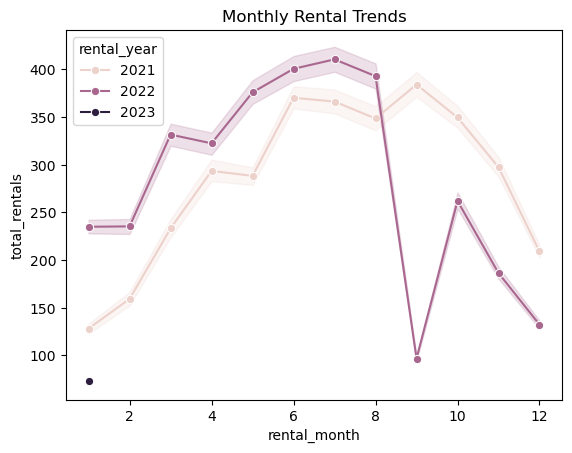

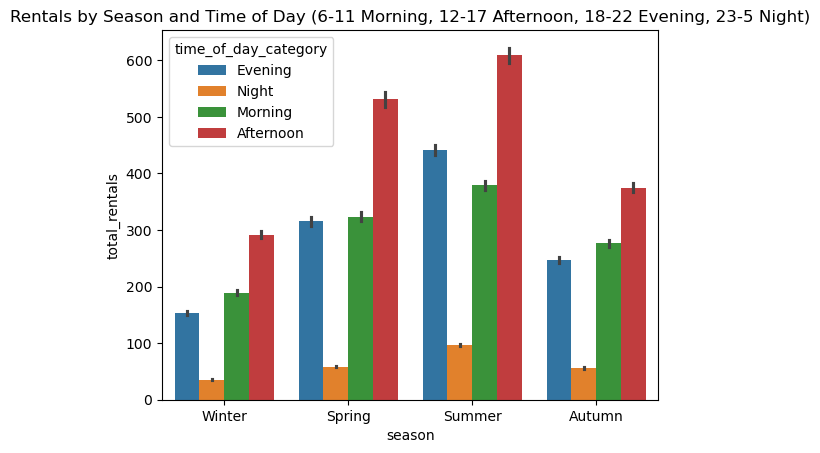

In [13]:
# Monthly rental trends by year
sns.lineplot(data=df_rental, x='rental_month', y='total_rentals', hue='rental_year', marker='o')
plt.title('Monthly Rental Trends')
plt.show()

# Rentals by Season and Time of Day
sns.barplot(data=df_rental, x='season', y='total_rentals', hue='time_of_day_category')
plt.title('Rentals by Season and Time of Day (6-11 Morning, 12-17 Afternoon, 18-22 Evening, 23-5 Night)')
plt.show()

# If the hour is between 6 and 11, it is Morning 
# If the hour is between 12 and 17, it is Afternoon 
# If the hour is between 18 and 22, it is Evening 
# Any other time is categorized as Night 

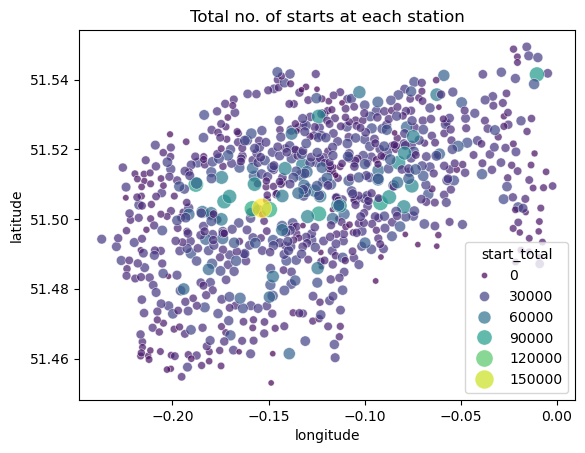

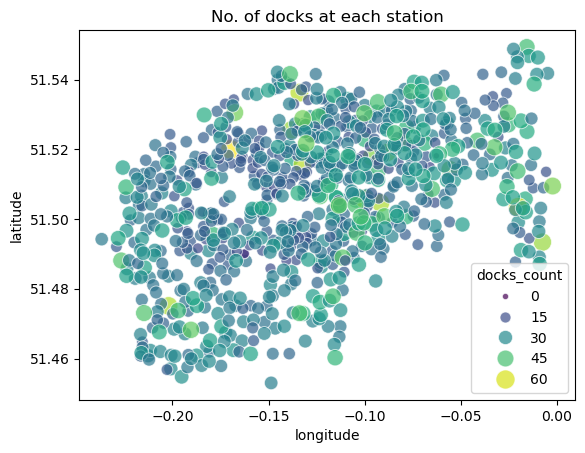

In [14]:
# Total no. of starts at each station
sns.scatterplot(
    data=df_station,
    x='longitude',
    y='latitude',
    hue='start_total',  # Color represents total no. of starts
    size='start_total', # Size represents total no. of starts
    sizes=(20, 200),    # Range of point sizes
    palette='viridis',  # Color palette (inferno, magma, plasma also good)
    alpha=0.7           # Transparency for overlap
)
plt.title('Total no. of starts at each station')
plt.show()

# Docks count at each station
sns.scatterplot(
    data=df_station,
    x='longitude',
    y='latitude',
    hue='docks_count',  # Color represents bike count
    size='docks_count', # Size represents bike count
    sizes=(20, 200),    # Range of point sizes
    palette='viridis',  # Color palette (inferno, magma, plasma also good)
    alpha=0.7           # Transparency for overlap
)
plt.title('No. of docks at each station')
plt.show()